# Project - Titanic Passenger Survival Analysis

## Problem Statement
- Perform Exploratory Data Analysis(EDA) using matplotlib library
- Create a insightful visualization to understand the factors that infulenced survival on the Titanic

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
%matplotlib inline

## Dataset
- Dataset **Titanic-Dataset.csv** is downloaded from Kaggle
- Link: https://www.kaggle.com/datasets/yasserh/titanic-dataset
- This dataset contains details of all passengers when the titanic drowned and some people died
- This dataset may contains of missing values

#### Loading dataset
- Reading the dataset using **read_csv** method from pandas
- This function converts the dataset in **Pandas DataFrame** 

In [61]:
df = pd.read_csv('Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Data Preparation
- Check null values using **isna()** method
- Check unique values using **unique()** method
- **sum()** displays how many values are null in particular column

In [62]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

- Now we have to check manually which are mandatory columns that shouldn't have null values
- As per the problem statement we need:
  1. Survived
  2. Pclass
  3. Sex
  4. Age
  5. Fare
- The **Age** column has some null values let's handle them

In [63]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [64]:
# again check null values for confirmation
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## EDA tasks
1. Overall survival rate
2. Survival rate based on gender
3. Survival rate based on passenger class
4. Survival rate based on age group
5. Age distribution 
6. Fare vs age

## Caluculations for visualization

#### Overall survival rate

In [65]:
# Overall survival rate
survived = (df['Survived']==1).sum()
died = (df['Survived']==0).sum()
total = df['Survived'].count()
print(survived,died,total)

342 549 891


#### Survival rate based on gender

In [66]:
# Survival rate based on gender - 'Sex'
gender_survival = df.groupby('Sex')['Survived'].mean()*100
gender_survival

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

In [67]:
# additional information based on gender - 'Sex'
gender_survived = df.groupby('Sex')['Survived'].sum()
gender_died = df.groupby('Sex')['Survived'].count() - df.groupby('Sex')['Survived'].sum()
gender_total = df.groupby('Sex')['Survived'].count()

print(gender_survived,gender_died,gender_total)

Sex
female    233
male      109
Name: Survived, dtype: int64 Sex
female     81
male      468
Name: Survived, dtype: int64 Sex
female    314
male      577
Name: Survived, dtype: int64


#### Survival rate based on passenger class

In [68]:
# Survival rate based on passenger class - 'Pclass'
Pclass_survival = df.groupby('Pclass')['Survived'].mean()*100

print(Pclass_survival)

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


In [69]:
# additional information based on passenger class - 'Pclass'
Pclass_total = df.groupby('Pclass')['Survived'].count()
Pclass_survived = df.groupby('Pclass')['Survived'].sum()
Pclass_died = Pclass_total - df.groupby('Pclass')['Survived'].sum()

print(Pclass_survived,Pclass_died,Pclass_total)

Pclass
1    136
2     87
3    119
Name: Survived, dtype: int64 Pclass
1     80
2     97
3    372
Name: Survived, dtype: int64 Pclass
1    216
2    184
3    491
Name: Survived, dtype: int64


#### Survival rate based on age group
- There is no age group column in the dataset but we have **Age** column
- So based on **Age** we have to create new column named **AgeGroup**
- **AgeGroup** column should contain only these values:
  1. Child
  2. Teen
  3. Adult
  4. Middle Age
  5. Senior

In [70]:
# Adding 'AgeGroup' column to dataframe
df['AgeGroup'] = pd.cut(df['Age'],bins=[0,12,19,30,45,90],labels=['Child','Teen','Adult','Middle Age','Senior'])
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Middle Age
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Middle Age
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Middle Age


In [71]:
# Survival rate based on age group - 'AgeGroup'
age_group_survival = df.groupby('AgeGroup')['Survived'].mean()*100

print(age_group_survival)

AgeGroup
Child         57.971014
Teen          41.052632
Adult         32.938389
Middle Age    42.574257
Senior        36.893204
Name: Survived, dtype: float64


C:\Users\user\AppData\Local\Temp\ipykernel_3652\2620449427.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_survival = df.groupby('AgeGroup')['Survived'].mean()*100


In [72]:
# Additional information based on age group - 'AgeGroup'
age_group_total = df.groupby('AgeGroup')['Survived'].count()
age_group_survived = df.groupby('AgeGroup')['Survived'].sum()
age_group_died = age_group_total - df.groupby('AgeGroup')['Survived'].sum()

print(age_group_survived,age_group_died,age_group_total)

AgeGroup
Child          40
Teen           39
Adult         139
Middle Age     86
Senior         38
Name: Survived, dtype: int64 AgeGroup
Child          29
Teen           56
Adult         283
Middle Age    116
Senior         65
Name: Survived, dtype: int64 AgeGroup
Child          69
Teen           95
Adult         422
Middle Age    202
Senior        103
Name: Survived, dtype: int64


C:\Users\user\AppData\Local\Temp\ipykernel_3652\2742365243.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_total = df.groupby('AgeGroup')['Survived'].count()
C:\Users\user\AppData\Local\Temp\ipykernel_3652\2742365243.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_survived = df.groupby('AgeGroup')['Survived'].sum()
C:\Users\user\AppData\Local\Temp\ipykernel_3652\2742365243.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future defa

#### Age Distribution
- Age distribution can be done only using **Age**
- We can use **Histogram** for age diatribution 
- And making more bins helps for better visualization

In [73]:
# No calculation required for Age Distribution

#### Fare vs Age
- We have to visualize **Fare** and **Age** using **Scatter plot**
- And also we can show who are survived at end based on **Survived** column

In [74]:
# No caluculations for Fare vs Age

## Data Visualization - Graphical Representation
- Using **subplots** for some important charts
- Additional charts are providing some more information
- Additional charts are represented at last

### Core Visualization

In [75]:
# Defining subplots figure 1
fig1, ax = plt.subplots(2,2,figsize=[10,10])

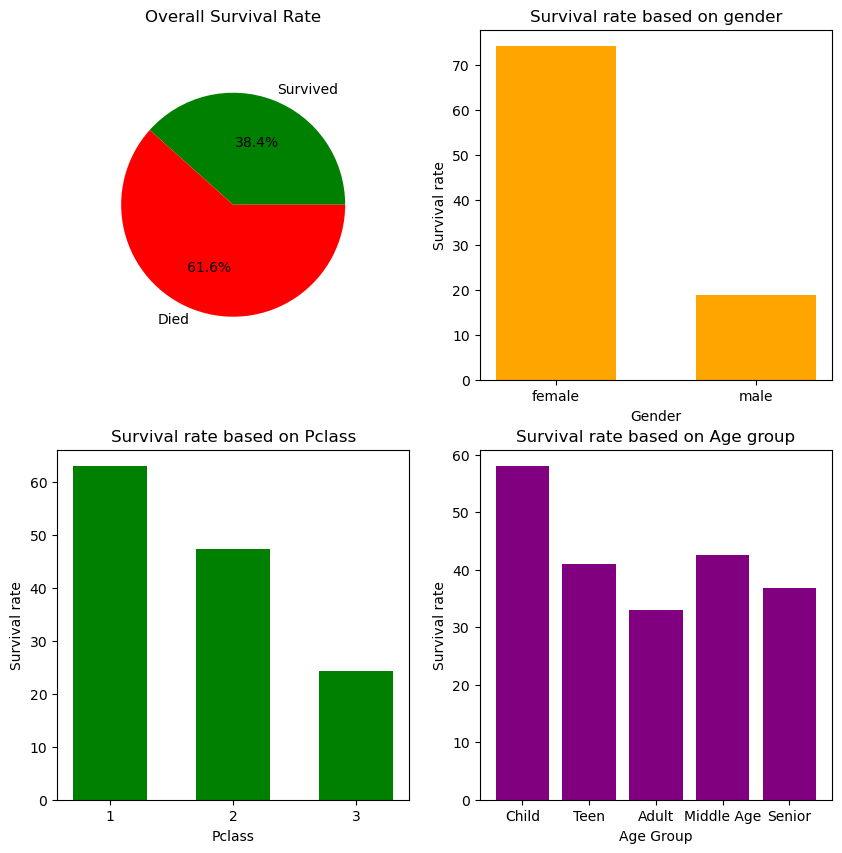

In [76]:
# Overall survival rate
ax[0,0].pie([survived,died],
            autopct='%0.1f%%',
            labels=['Survived','Died'],
            colors=['green','red'],
            radius=0.8)
ax[0,0].set_title('Overall Survival Rate')

# Survival rate based on gender
xpos1 = np.arange(len(gender_survival))
ax[0,1].bar(xpos1,gender_survival.values,label=gender_survival.index,width=0.6,color='orange')
ax[0,1].set_title('Survival rate based on gender')
ax[0,1].set_xlabel('Gender')
ax[0,1].set_xticks(xpos1,gender_survival.index)
ax[0,1].set_ylabel('Survival rate')

# Survival rate based on passenger class
xpos2 = np.arange(len(Pclass_survival))
ax[1,0].bar(xpos2,Pclass_survival.values,label=Pclass_survival.index,width=0.6,color='green')
ax[1,0].set_title('Survival rate based on Pclass')
ax[1,0].set_xlabel('Pclass')
ax[1,0].set_xticks(xpos2,Pclass_survival.index)
ax[1,0].set_ylabel('Survival rate')

# Survival rate based on age group
xpos3 = np.arange(len(age_group_survival))
ax[1,1].bar(xpos3,age_group_survival.values,label=age_group_survival.index,color='purple')
ax[1,1].set_title('Survival rate based on Age group')
ax[1,1].set_xlabel('Age Group')
ax[1,1].set_xticks(xpos3,age_group_survival.index)
ax[1,1].set_ylabel('Survival rate')

plt.show()
fig1.savefig("Survival_Rate.png", dpi=300)

- INSIGHTS:
  1. **Overall Survival rate :** from total passengers
     - **38.4%** i.e **342** were survived
     - **61.6%** i.e **549** were died
  2. **Survival rate based on gender:**
     - from total female passengers **314** only **233** i.e **74.2%** were survived
     - from total male passengers **577** only **109** i.e **18.8%** were survived
  3. **Survival rate based on Pclass:**
     - from total class-1 passengers **216** only **136** i.e **62.9%** were survived
     - from total class-2 passengers **184** only **87** i.e **47.2%** were survived
     - from total class-3 passengers **491** only **119** i.e **24.2%** were survived
  4. **Survival rate based on AgeGroup:**
     - from total child people **69** only **40** i.e **57.9%** were survived
     - from total teen people **95** only **39** i.e **41%** were survived
     - from total adult people **422** only **139** i.e **32.9%** were survived
     - from total middle age people **202** only **86** i.e **42.5%** were survived
     - from total senior people **103** only **38** i.e **36.8%** were survived

In [77]:
# Defining subplots figure 2 
fig2, ax2 = plt.subplots(1,2,figsize=[10,5])

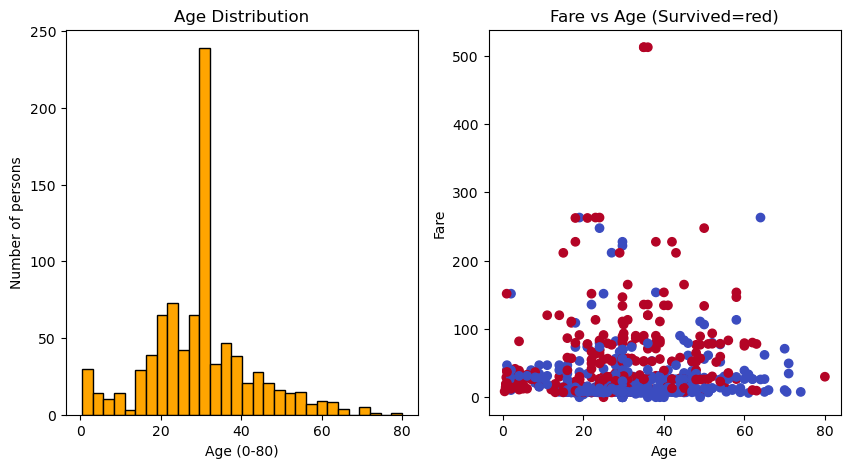

In [78]:
# Age Distribution
ax2[0].hist(df.Age,bins=30,color='orange',edgecolor='black')
ax2[0].set_title('Age Distribution')
ax2[0].set_xlabel('Age (0-80)')
ax2[0].set_ylabel('Number of persons')

# Fare vs Age plot
ax2[1].scatter(df.Age,df.Fare,c=df.Survived,cmap='coolwarm')
ax2[1].set_title('Fare vs Age (Survived=red)')
ax2[1].set_xlabel('Age')
ax2[1].set_ylabel('Fare')

plt.show()
fig2.savefig("Age_Fare.png", dpi=300)

- INSIGHTS:
  1. **Age Distribution:**
     - there are more passengers in age group between **20-40**
  2. **Fare vs Age:**
     - red dots denote survived people and who paid high fare i.e **500+** was survived


### Advanced Visualization
1. Gender based Visualzation
2. Pclass based Visualiation
3. Age Group based Visualization

#### Gender based visualization

In [79]:
# Survival rate (pie), survived people & died people (bar + pie)
fig3, ax3 = plt.subplots(2,2,figsize=[10,10])

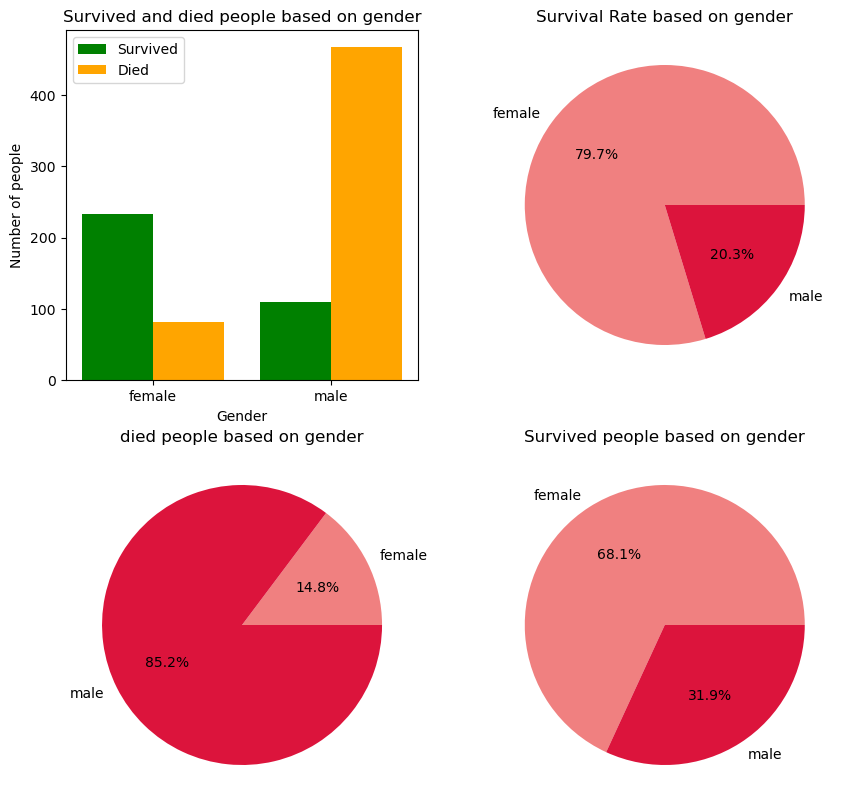

In [80]:
xpos4 = np.arange(len(gender_survived))
ax3[0,0].bar(xpos4-0.2,gender_survived.values,label='Survived',width=0.4,color='green')
ax3[0,0].bar(xpos4+0.2,gender_died.values,label='Died',width=0.4,color='orange')
ax3[0,0].set_xticks(xpos4,gender_survived.index)
ax3[0,0].set_title('Survived and died people based on gender')
ax3[0,0].set_xlabel('Gender')
ax3[0,0].set_ylabel('Number of people')
ax3[0,0].legend(labels=['Survived','Died'])

ax3[0,1].pie(gender_survival,autopct='%0.1f%%',labels=gender_survival.index,colors=['lightcoral','crimson'])
ax3[0,1].set_title('Survival Rate based on gender')

ax3[1,0].pie(gender_died,autopct='%0.1f%%',labels=gender_died.index,colors=['lightcoral','crimson'])
ax3[1,0].set_title('died people based on gender')

ax3[1,1].pie(gender_survived,autopct='%0.1f%%',labels=gender_survived.index,colors=['lightcoral','crimson'])
ax3[1,1].set_title('Survived people based on gender')

plt.show()
fig3.savefig("Gender_based.png", dpi=300)

- INSIGHTS:
  1. **Survived and died people based on gender:**
     - in total female passengers **314** **81** are died and **233** are survived
     - in total male passengers **577** **468** are died and **109** are survived
  2. **Survival rate based on gender:**
     - female passengers survival rate is **74.2%**
     - male passengers survival rate is **18.8%**
  4. **Died people based on gender:**
     - died female passengers are **14.8%** form total died passengers
     - died male passengers are **85.2%** from total died passengers
  5. **Survived people based on gender:**
     - survived female passengers are **68.1%** from total survived passengers
     - survived male passengers are **31.9%** from total survived passengers

#### Pclass based visualization

In [81]:
# Survival rate (pie), survived people & died people (bar + pie)
fig4, ax4 = plt.subplots(2,2,figsize=[10,10])

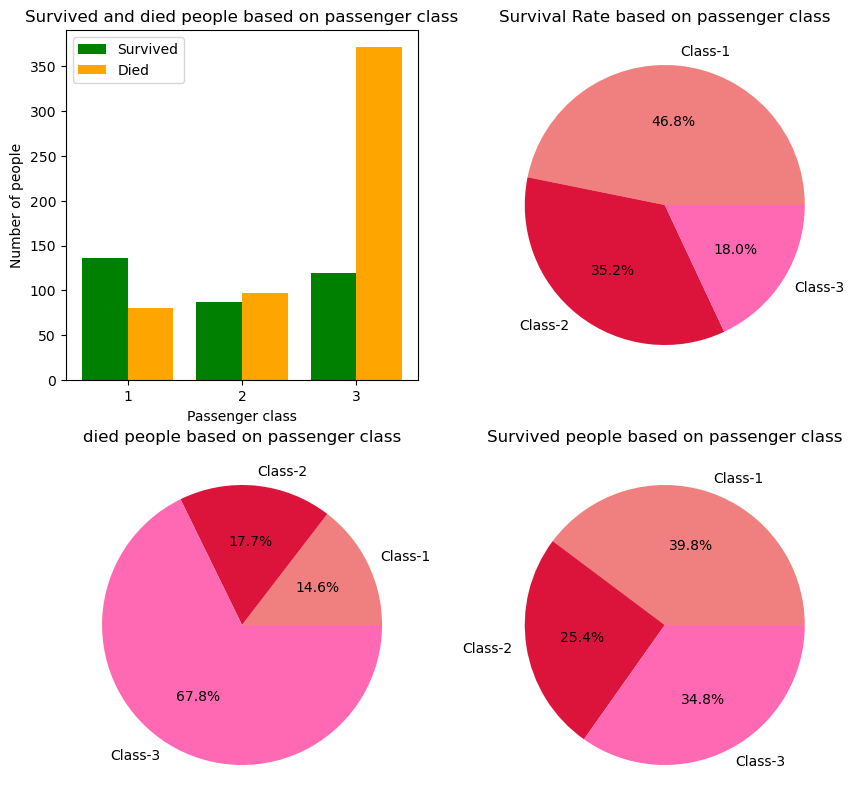

In [82]:
xpos5 = np.arange(len(Pclass_survived))
ax4[0,0].bar(xpos5-0.2,Pclass_survived.values,label='Survived',width=0.4,color='green')
ax4[0,0].bar(xpos5+0.2,Pclass_died.values,label='Died',width=0.4,color='orange')
ax4[0,0].set_xticks(xpos5,Pclass_survived.index)
ax4[0,0].set_title('Survived and died people based on passenger class')
ax4[0,0].set_xlabel('Passenger class')
ax4[0,0].set_ylabel('Number of people')
ax4[0,0].legend(labels=['Survived','Died'])

classes = ['Class-1','Class-2','Class-3']

ax4[0,1].pie(Pclass_survival,autopct='%0.1f%%',labels=classes,colors=['lightcoral','crimson','hotpink'])
ax4[0,1].set_title('Survival Rate based on passenger class')

ax4[1,0].pie(Pclass_died,autopct='%0.1f%%',labels=classes,colors=['lightcoral','crimson','hotpink'])
ax4[1,0].set_title('died people based on passenger class')

ax4[1,1].pie(Pclass_survived,autopct='%0.1f%%',labels=classes,colors=['lightcoral','crimson','hotpink'])
ax4[1,1].set_title('Survived people based on passenger class')

plt.show()
fig4.savefig("Pclass_based.png", dpi=300)

- INSIGHTS:
  1. **Survived and died people based on passenger class:**
     - in total class-1 passengers **216** **80** are died and **136** are survived
     - in total class-2 passengers **184** **97** are died and **87** are survived
     - in total class-3 passengers **491** **372** are died and **119** are survived
  2. **Survival rate based on passenger class:**
     - class-1 passengers survival rate is **46.8%**
     - class-2 passengers survival rate is **35.2%**
     - class-3 passengers survival rate is **18.0%**
  3. **Died people based on passenger class:**
     - died class-1 passengers are **14.6%** form total died passengers
     - died class-2 passengers are **17.7%** from total died passengers
     - died class-3 passengers are **67.8%** from total died passengers
  4. **Survived people based on gender:**
     - survived class-1 passengers are **39.8%** from total survived passengers
     - survived class-2 passengers are **25.4%** from total survived passengers
     - survived class-3 passengers are **34.8%** from total survived passengers

#### Age Group based Visualization

In [83]:
# Survival rate (pie), survived people & died people (bar + pie)
fig5, ax5 = plt.subplots(2,2,figsize=[10,10])

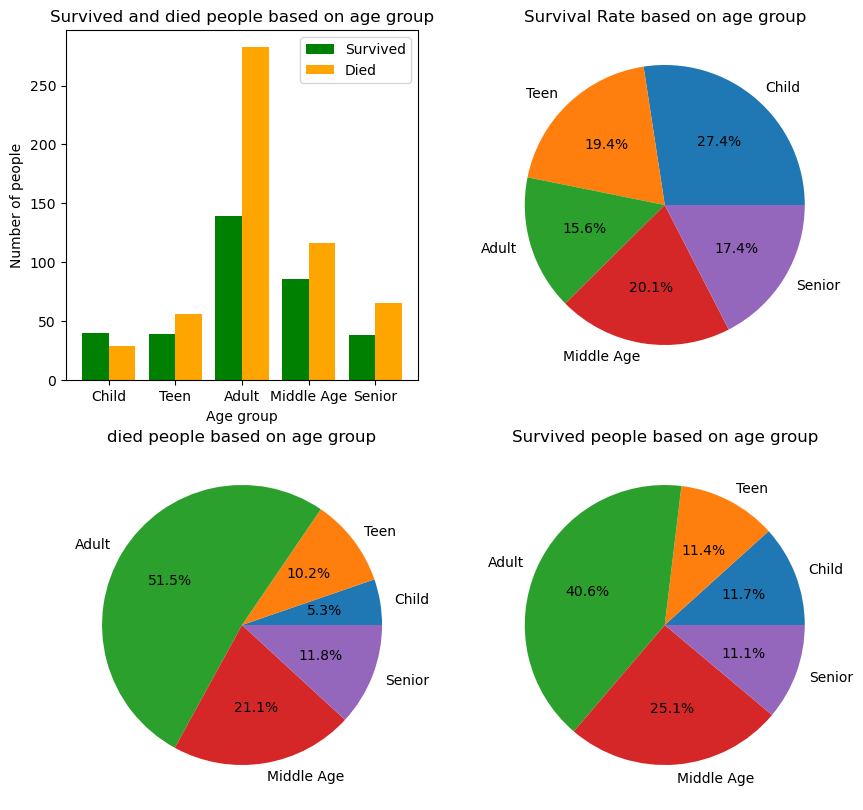

In [84]:
xpos6 = np.arange(len(age_group_survived))
ax5[0,0].bar(xpos6-0.2,age_group_survived.values,label='Survived',width=0.4,color='green')
ax5[0,0].bar(xpos6+0.2,age_group_died.values,label='Died',width=0.4,color='orange')
ax5[0,0].set_xticks(xpos6,age_group_survived.index)
ax5[0,0].set_title('Survived and died people based on age group')
ax5[0,0].set_xlabel('Age group')
ax5[0,0].set_ylabel('Number of people')
ax5[0,0].legend(labels=['Survived','Died'])

ax5[0,1].pie(age_group_survival,autopct='%0.1f%%',labels=age_group_survival.index)
ax5[0,1].set_title('Survival Rate based on age group')

ax5[1,0].pie(age_group_died,autopct='%0.1f%%',labels=age_group_died.index)
ax5[1,0].set_title('died people based on age group')

ax5[1,1].pie(age_group_survived,autopct='%0.1f%%',labels=age_group_survived.index)
ax5[1,1].set_title('Survived people based on age group')

plt.show()
fig5.savefig("AgeGroup_based.png", dpi=300)

- INSIGHTS:
  1. **Survived and died people based on age group:**
     - in total child passengers **69** **29** are died and **40** are survived
     - in total teen passengers **95** **56** are died and **39** are survived
     - in total adult passengers **422** **283** are died and **139** are survived
     - in total middle age passengers **202** **116** are died and **86** are survived
     - in total senior passengers **103** **65** are died and **119** are survived
  2. **Survival rate based on age group:**
     - child passengers survival rate is **27.4%**
     - teen passengers survival rate is **19.4%**
     - adult passengers survival rate is **15.6%**
     - middle age passengers survival rate is **20.1%**
     - senior passengers survival rate is **17.4%**
  3. **Died people based on age group:**
     - died child passengers are **5.3%** form total died passengers
     - died teen passengers are **10.2%** from total died passengers
     - died adult passengers are **51.5%** from total died passengers
     - died middle age passengers are **21.1%** from total died passengers
     - died senior passengers are **11.8%** from total died passengers
  4. **Survived people based age group:**
     - survived child passengers are **11.7%** from total survived passengers
     - survived teen passengers are **11.4%** from total survived passengers
     - survived adult passengers are **40.6%** from total survived passengers
     - survived middle age passengers are **25.1%** from total survived passengers
     - survived senior passengers are **11.1%** from total survived passengers

## Conclusion 
1. female and child passengers have more survival rate.
2. most of the male passengers were died
3. most of the middle age, adult passengers died
4. most of the class-3 people died